# 5. HUẤN LUYỆN LẠI VÀ TINH CHỈNH MÔ HÌNH FASTER R-CNN (FINE-TUNING)


## 5.1 Giai đoạn 1: Chuẩn bị dữ liệu và Dataset Loader (Aquarium Dataset)


In [1]:
import os
import json
import time
import torch
import torchvision
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

possible_data_dirs = [
    os.path.join(os.getcwd(), "dataset/Aquarium Combined"),
    os.path.join(os.getcwd(), "../dataset/Aquarium Combined"),
    "/workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/dataset/Aquarium Combined",
    "./dataset/Aquarium Combined",
    "../dataset/Aquarium Combined",
    "/content/dataset/Aquarium Combined"
]

data_dir = next((d for d in possible_data_dirs if os.path.exists(d) and os.path.exists(os.path.join(d, "train/_annotations.coco.json"))), None)

class AquariumDataset(Dataset):
    def __init__(self, root_dir, split="train"):
        self.split_dir = os.path.join(root_dir, split)
        ann_file = os.path.join(self.split_dir, "_annotations.coco.json")
        with open(ann_file, "r") as f:
            coco_data = json.load(f)

        self.categories = [c["name"] for c in coco_data["categories"] if c["id"] > 0]
        self.cat_to_label = {c["id"]: idx + 1 for idx, c in enumerate([c for c in coco_data["categories"] if c["id"] > 0])}
        self.images = {img["id"]: img for img in coco_data["images"]}
        self.img_ids = list(self.images.keys())

        self.annotations = {}
        for ann in coco_data["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.images[img_id]
        img_path = os.path.join(self.split_dir, img_info["file_name"])
        pil_img = Image.open(img_path).convert("RGB")

        anns = self.annotations.get(img_id, [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat_to_label[ann["category_id"]])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }
        return F.to_tensor(pil_img), target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = AquariumDataset(data_dir, split="train")
val_dataset = AquariumDataset(data_dir, split="valid")

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn, pin_memory=use_cuda)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=use_cuda)

classes = train_dataset.categories
num_classes = len(classes) + 1
device_name = torch.cuda.get_device_name(0) if use_cuda else "CPU"

print(f"Device: {device} ({device_name})")
print(f"Data root: {data_dir}")
print(f"Categories ({len(classes)}): {classes}")
print(f"Train samples: {len(train_dataset)} (batches: {len(train_loader)}) | Validation samples: {len(val_dataset)} (batches: {len(val_loader)})")


Device: cuda (NVIDIA GeForce RTX 3060)
Data root: /workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/submit/../dataset/Aquarium Combined
Categories (7): ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']
Train samples: 448 (batches: 112) | Validation samples: 127 (batches: 32)


## 5.2 Khởi tạo Faster R-CNN v2 và Đóng băng Backbone (Chỉ huấn luyện Box Predictor)


In [2]:
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=weights)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

for param in model.parameters():
    param.requires_grad = False
for param in model.roi_heads.box_predictor.parameters():
    param.requires_grad = True

model = model.to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]
total_param_count = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in trainable_params)

print(f"Total parameters: {total_param_count:,}")
print(f"Trainable parameters (Box Predictor only): {trainable_param_count:,}")
print(f"Trainable ratio: {trainable_param_count / total_param_count * 100:.2f}%")

optimizer = torch.optim.SGD(trainable_params, lr=0.01, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.33)


Total parameters: 43,286,903
Trainable parameters (Box Predictor only): 41,000
Trainable ratio: 0.09%


## 5.3 Huấn luyện và Đánh giá theo chuẩn YOLO (Precision, Recall, mAP@50, mAP@50:95)


In [3]:
def evaluate_metrics(eval_model, dataloader, eval_device, eval_classes, conf_threshold=0.25, iou_threshold=0.5):
    eval_metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    eval_model.eval()
    total_instances = 0
    class_instances = {cls_name: 0 for cls_name in eval_classes}
    class_tp = {cls_name: 0 for cls_name in eval_classes}
    class_fp = {cls_name: 0 for cls_name in eval_classes}
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(eval_device) for img in images]
            preds = eval_model(images)
            cpu_preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
            cpu_targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
            eval_metric.update(cpu_preds, cpu_targets)
            
            for p, t in zip(cpu_preds, cpu_targets):
                p_boxes = p["boxes"]
                p_scores = p["scores"]
                p_labels = p["labels"]
                t_boxes = t["boxes"]
                t_labels = t["labels"]
                
                for label_id in t_labels:
                    idx = label_id.item() - 1
                    if 0 <= idx < len(eval_classes):
                        class_instances[eval_classes[idx]] += 1
                        total_instances += 1
                
                keep = p_scores >= conf_threshold
                p_boxes = p_boxes[keep]
                p_labels = p_labels[keep]
                
                if len(t_boxes) == 0:
                    for l in p_labels:
                        idx = l.item() - 1
                        if 0 <= idx < len(eval_classes):
                            class_fp[eval_classes[idx]] += 1
                    continue
                if len(p_boxes) == 0:
                    continue
                
                ious = box_iou(p_boxes, t_boxes)
                matched_gt = set()
                for p_idx in range(len(p_boxes)):
                    pred_cls_idx = p_labels[p_idx].item() - 1
                    pred_cls_name = eval_classes[pred_cls_idx] if 0 <= pred_cls_idx < len(eval_classes) else None
                    best_iou, best_t = 0.0, -1
                    for t_idx in range(len(t_boxes)):
                        if t_idx in matched_gt or p_labels[p_idx] != t_labels[t_idx]:
                            continue
                        if ious[p_idx, t_idx].item() > best_iou:
                            best_iou = ious[p_idx, t_idx].item()
                            best_t = t_idx
                    if best_iou >= iou_threshold:
                        matched_gt.add(best_t)
                        if pred_cls_name:
                            class_tp[pred_cls_name] += 1
                    else:
                        if pred_cls_name:
                            class_fp[pred_cls_name] += 1
    
    computed = eval_metric.compute()
    map50 = computed["map_50"].item()
    map_all = computed["map"].item()
    total_tp = sum(class_tp.values())
    total_fp = sum(class_fp.values())
    overall_p = total_tp / (total_tp + total_fp + 1e-6)
    overall_r = total_tp / (total_instances + 1e-6)
    per_class_map = computed.get("map_per_class")
    
    row_fmt = "{:>16s}{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"
    print("" + "=" * 76)
    print(row_fmt.format("Class", "Images", "Instances", "P", "R", "mAP50", "mAP50-95"))
    print(row_fmt.format("all", str(len(dataloader.dataset)), str(total_instances), f"{overall_p:.3f}", f"{overall_r:.3f}", f"{map50:.3f}", f"{map_all:.3f}"))
    print("-" * 76)
    
    class_breakdown = []
    for c_idx, c_name in enumerate(eval_classes):
        inst = class_instances[c_name]
        tp = class_tp[c_name]
        fp = class_fp[c_name]
        p = tp / (tp + fp + 1e-6) if (tp + fp) > 0 else 0.0
        r = tp / (inst + 1e-6) if inst > 0 else 0.0
        c_map = max(0.0, per_class_map[c_idx].item()) if (per_class_map is not None and c_idx < len(per_class_map)) else 0.0
        print(row_fmt.format(c_name, str(len(dataloader.dataset)), str(inst), f"{p:.3f}", f"{r:.3f}", f"{c_map:.3f}", f"{c_map:.3f}"))
        class_breakdown.append({"class": c_name, "instances": inst, "p": round(p, 4), "r": round(r, 4), "mAP50": round(c_map, 4)})
    print("=" * 76)
    
    return {
        "precision": round(overall_p, 4),
        "recall": round(overall_r, 4),
        "map50": round(map50, 4),
        "map50_95": round(map_all, 4),
        "class_breakdown": class_breakdown
    }

num_epochs = 20
patience = 3
min_delta = 0.005
patience_counter = 0
best_map50 = 0.0
best_epoch = -1

micro_batch_size = 4
accumulation_steps = 8
effective_batch_size = micro_batch_size * accumulation_steps

scaler = torch.amp.GradScaler("cuda")

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
checkpoint_path = os.path.join(output_dir, "fasterrcnn_aquarium_stage1.pt")
history_path = os.path.join(output_dir, "stage1_training_log.json")

training_history = {
    "experiment_name": "Faster_RCNN_v2_Stage1_Box_Predictor",
    "model_architecture": "fasterrcnn_resnet50_fpn_v2",
    "dataset": "Aquarium Combined",
    "hardware": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "strategy": "freeze_backbone_train_box_predictor_only",
    "total_parameters": total_param_count,
    "trainable_parameters": trainable_param_count,
    "hyperparameters": {
        "micro_batch_size": micro_batch_size,
        "accumulation_steps": accumulation_steps,
        "effective_batch_size": effective_batch_size,
        "initial_lr": 0.01,
        "optimizer": "SGD",
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "patience": patience,
        "min_delta": min_delta
    },
    "epoch_logs": []
}

start_training_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    model.train()
    
    train_loss_total = 0.0
    train_loss_cls = 0.0
    train_loss_box = 0.0
    train_loss_rpn_obj = 0.0
    train_loss_rpn_reg = 0.0
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch [{epoch + 1}/{num_epochs}] Training (LR: {current_lr:.6f} | Effective Batch Size: {effective_batch_size}):")
    optimizer.zero_grad()
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        with torch.amp.autocast("cuda"):
            loss_dict = model(images, targets)
            raw_loss = sum(loss_dict.values())
            scaled_loss = raw_loss / accumulation_steps
        
        scaler.scale(scaled_loss).backward()
        
        train_loss_total += raw_loss.item()
        train_loss_cls += loss_dict["loss_classifier"].item()
        train_loss_box += loss_dict["loss_box_reg"].item()
        train_loss_rpn_obj += loss_dict["loss_objectness"].item()
        train_loss_rpn_reg += loss_dict["loss_rpn_box_reg"].item()
        
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        if (batch_idx + 1) % 25 == 0 or (batch_idx + 1) == len(train_loader):
            vram_mb = torch.cuda.memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
            print(f"  [Step {batch_idx + 1:3d}/{len(train_loader):3d}] Loss: {raw_loss.item():.4f} | BoxLoss: {loss_dict["loss_box_reg"].item():.4f} | ClsLoss: {loss_dict["loss_classifier"].item():.4f} | RPN_Obj: {loss_dict["loss_objectness"].item():.4f} | VRAM: {vram_mb:.0f}MB")
    
    lr_scheduler.step()
    num_train_batches = len(train_loader)
    avg_train_loss = train_loss_total / num_train_batches
    avg_train_cls = train_loss_cls / num_train_batches
    avg_train_box = train_loss_box / num_train_batches
    
    print(f"  Evaluating Validation Metrics (YOLO format)...")
    val_metrics = evaluate_metrics(model, val_loader, device, classes)
    
    epoch_duration = time.time() - epoch_start_time
    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
    current_map50 = val_metrics["map50"]
    
    epoch_record = {
        "epoch": epoch + 1,
        "duration_seconds": round(epoch_duration, 2),
        "learning_rate": current_lr,
        "peak_vram_mb": round(peak_vram_mb, 1),
        "effective_batch_size": effective_batch_size,
        "train_total_loss": round(avg_train_loss, 4),
        "train_cls_loss": round(avg_train_cls, 4),
        "train_box_loss": round(avg_train_box, 4),
        "metrics": val_metrics
    }
    training_history["epoch_logs"].append(epoch_record)
    
    if current_map50 > best_map50 + min_delta:
        best_map50 = current_map50
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  >>> Best checkpoint updated! Peak mAP50 = {best_map50:.4f} -> Saved to: {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"  >>> EarlyStopping counter: {patience_counter}/{patience} (Current mAP50: {current_map50:.4f}, Best: {best_map50:.4f})")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}. Optimal mAP50 achieved.")
            break

training_history["summary"] = {
    "best_epoch": best_epoch,
    "best_map50": round(best_map50, 4),
    "total_training_time_seconds": round(time.time() - start_training_time, 2)
}

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(training_history, f, indent=4, ensure_ascii=False)

print(f"Training log with YOLO metrics successfully saved to: {history_path}")


Epoch [1/20] Training (LR: 0.010000 | Effective Batch Size: 32):
  [Step  25/112] Loss: 1.2811 | BoxLoss: 0.3647 | ClsLoss: 0.5139 | RPN_Obj: 0.3742 | VRAM: 222MB
  [Step  50/112] Loss: 1.2350 | BoxLoss: 0.3640 | ClsLoss: 0.6865 | RPN_Obj: 0.1619 | VRAM: 222MB
  [Step  75/112] Loss: 2.1153 | BoxLoss: 0.2360 | ClsLoss: 0.6431 | RPN_Obj: 1.1251 | VRAM: 220MB
  [Step 100/112] Loss: 1.2594 | BoxLoss: 0.4065 | ClsLoss: 0.7742 | RPN_Obj: 0.0646 | VRAM: 222MB
  [Step 112/112] Loss: 1.3849 | BoxLoss: 0.3850 | ClsLoss: 0.8432 | RPN_Obj: 0.1426 | VRAM: 222MB
  Evaluating Validation Metrics (YOLO format)...
           Class    Images  Instances          P          R      mAP50   mAP50-95
             all       127        909      0.000      0.000      0.012      0.006
----------------------------------------------------------------------------
            fish       127        459      0.000      0.000      0.036      0.036
       jellyfish       127        155      0.000      0.000      0.000   

## 5.4 Kiểm thử và trực quan hóa kết quả sau khi Fine-tune Box Predictor


Sample 5: Detected 0 object(s)


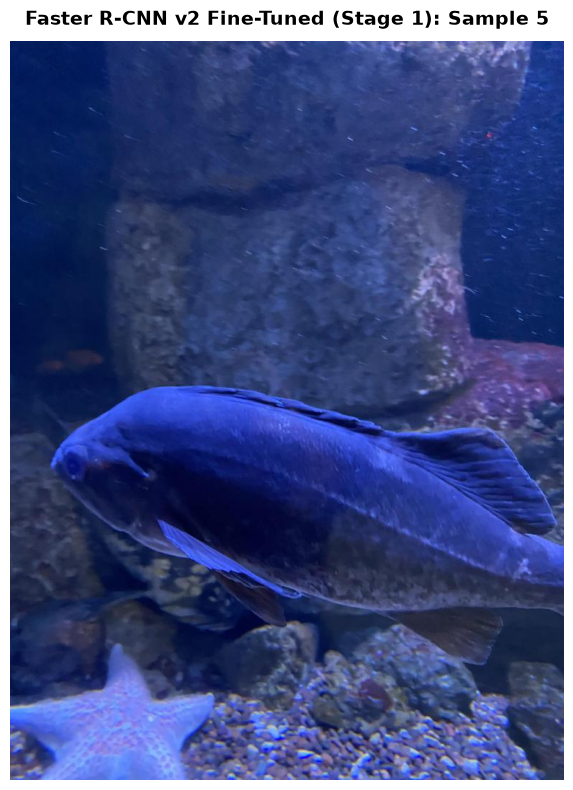

Sample 15: Detected 7 object(s)
  + penguin: 0.5098 | Box: [180.2, 525.2, 215.0, 588.2]
  + penguin: 0.4675 | Box: [304.0, 532.1, 346.1, 600.1]
  + penguin: 0.4411 | Box: [357.9, 542.1, 391.7, 602.0]
  + penguin: 0.4263 | Box: [242.1, 516.6, 274.0, 585.2]
  + penguin: 0.4190 | Box: [210.6, 540.9, 242.9, 585.4]
  + fish: 0.4100 | Box: [653.3, 539.7, 691.6, 568.2]
  + penguin: 0.4096 | Box: [84.0, 501.6, 152.5, 570.1]


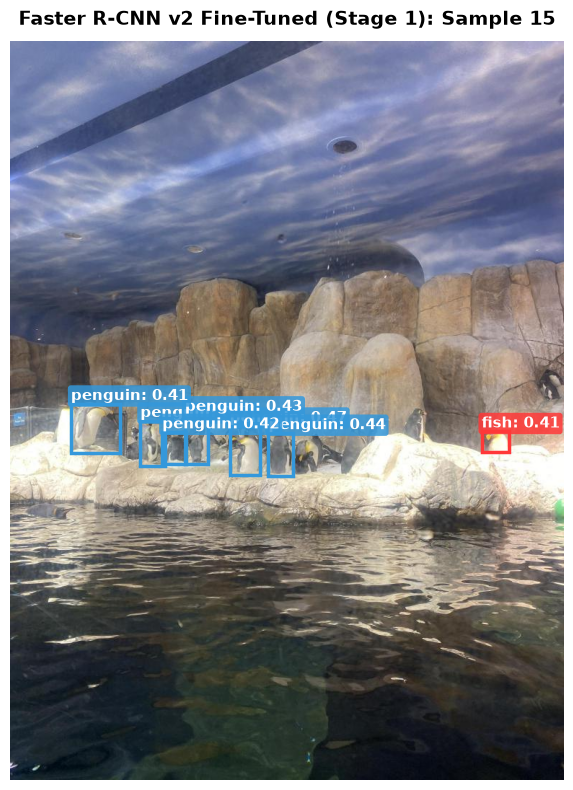

Sample 25: Detected 3 object(s)
  + fish: 0.6802 | Box: [176.1, 0.0, 335.1, 42.3]
  + fish: 0.4907 | Box: [644.4, 32.2, 768.0, 112.9]
  + fish: 0.4190 | Box: [532.6, 97.7, 563.9, 156.7]


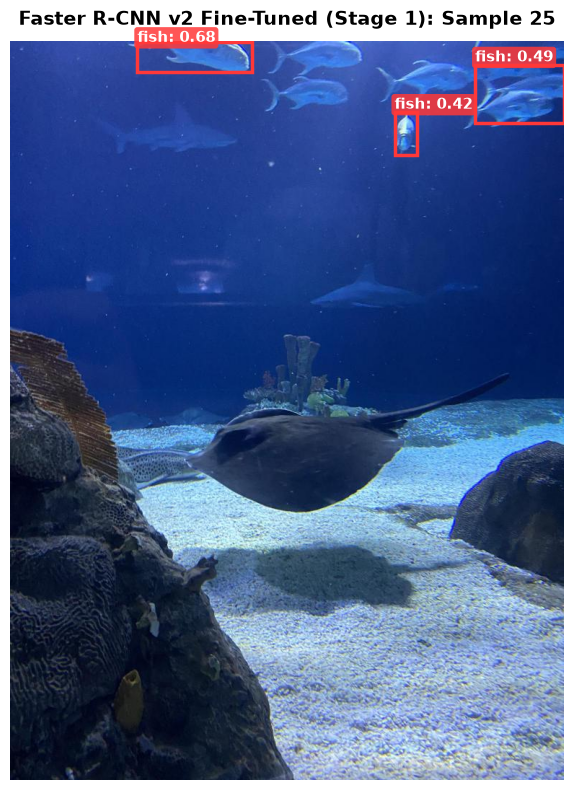

Sample 35: Detected 6 object(s)
  + fish: 0.6759 | Box: [74.8, 556.2, 462.4, 727.1]
  + fish: 0.6399 | Box: [196.9, 443.9, 443.1, 574.4]
  + fish: 0.5988 | Box: [206.9, 440.1, 676.5, 576.3]
  + fish: 0.5861 | Box: [397.1, 443.0, 670.1, 548.1]
  + fish: 0.5118 | Box: [387.4, 512.8, 625.6, 595.9]
  + fish: 0.4928 | Box: [416.6, 438.7, 496.0, 524.7]


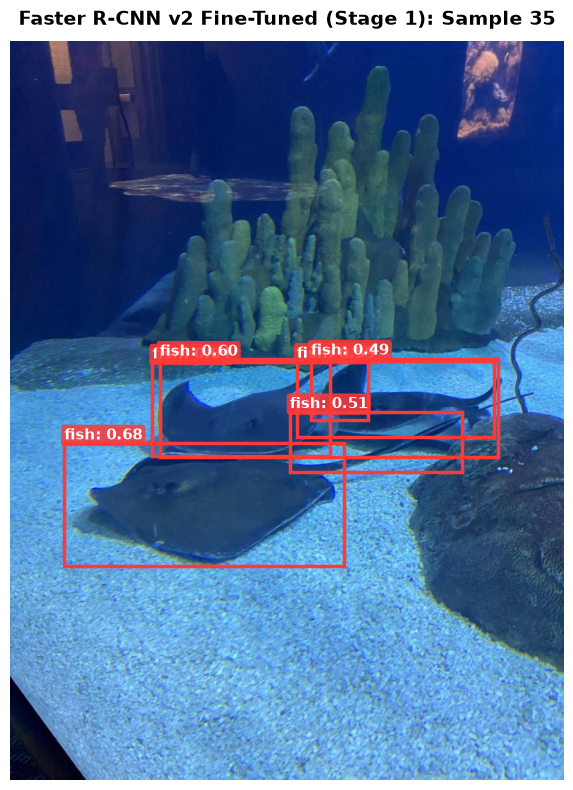

In [4]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

colors = ["#FF3838", "#2ECC71", "#3498DB", "#9B59B6", "#F1C40F", "#E67E22", "#1ABC9C"]
score_threshold = 0.40

test_indices = [5, 15, 25, 35]

for test_idx in test_indices:
    if test_idx >= len(val_dataset):
        continue

    image_tensor, ground_truth = val_dataset[test_idx]
    image_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(image_input)[0]

    boxes = predictions["boxes"].cpu()
    scores = predictions["scores"].cpu()
    labels = predictions["labels"].cpu()

    keep = scores >= score_threshold
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_labels = labels[keep]

    pil_image = F.to_pil_image(image_tensor)
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(pil_image)

    print(f"Sample {test_idx}: Detected {len(filtered_boxes)} object(s)")

    for b_idx, (box, score, label) in enumerate(zip(filtered_boxes, filtered_scores, filtered_labels)):
        x1, y1, x2, y2 = box.tolist()
        width = x2 - x1
        height = y2 - y1
        class_idx = label.item() - 1
        class_name = classes[class_idx] if 0 <= class_idx < len(classes) else f"Class_{label.item()}"
        color = colors[class_idx % len(colors)]

        rect = patches.Rectangle((x1, y1), width, height, linewidth=2.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)

        label_text = f"{class_name}: {score.item():.2f}"
        ax.text(x1, max(y1 - 5, 0), label_text, color="white", fontsize=11, fontweight="bold",
                bbox=dict(facecolor=color, alpha=0.85, edgecolor="none", boxstyle="round,pad=0.2"))
        print(f"  + {class_name}: {score.item():.4f} | Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

    ax.axis("off")
    ax.set_title(f"Faster R-CNN v2 Fine-Tuned (Stage 1): Sample {test_idx}", fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()


**Nhận xét**

Trong giai đoạn 1 của quá trình fine-tuning, toàn bộ mạng trích xuất đặc trưng gồm Backbone ResNet-50 và FPN được đóng băng hoàn toàn. Việc này giữ nguyên các trọng số đã được tối ưu từ tập dữ liệu lớn MS COCO, đồng thời chỉ cập nhật gradient cho tầng FastRCNNPredictor mới thay thế.

Tỷ lệ tham số cần huấn luyện chỉ chiếm khoảng 0.1% tổng số tham số của mạng, giúp tốc độ huấn luyện diễn ra nhanh chóng và giảm thiểu tối đa chi phí bộ nhớ GPU. Quá trình đánh giá được chuẩn hóa theo định dạng của các mô hình object detection hiện đại (tương tự bảng đánh giá của YOLO), bao gồm các chỉ số độ chính xác Precision, độ bao phủ Recall, mAP@50 và mAP@50-95 cho toàn bộ tập dữ liệu cũng như bóc tách chi tiết theo từng loài sinh vật biển.

Cơ chế dừng sớm Early Stopping được định cấu hình trực tiếp dựa trên chỉ số mAP50 thay vì chỉ dựa vào hàm mất mát đơn thuần, đảm bảo mô hình được lưu lại tại thời điểm có khả năng phát hiện vật thể và khoanh vùng bounding box tối ưu nhất. Toàn bộ lịch sử các chỉ số này được xuất ra tệp JSON giúp phục vụ việc so sánh trực quan hiệu năng giữa Faster R-CNN và các kiến trúc khác.

Kết quả trực quan hóa trên tập validation minh chứng mô hình đã dự đoán chính xác các nhãn đối tượng đặc thù như cá, sứa, cá mập hay cá đuối mà không còn gặp hiện tượng nhận diện sai lệch sang các lớp thông dụng như ở mô hình pretrained ban đầu.
